In [2]:
library(homologene)
library(stringr)
library(dplyr)
library(ggplot2)
library(ggpubr)

mouse <- read.csv('../data/GSE147460_RSEM_TPM_table.csv')


mouse_human <- homologene(mouse$Name, inTax = 10090, outTax = 9606)  # 10090=mouse, 9606=human
mouse_human <- mouse_human[!duplicated(mouse_human[,'10090']),]
rownames(mouse_human) <- mouse_human[,"10090"]

mouse$human_gene <- mouse_human[mouse$Name,'9606']
mouse <- mouse[!duplicated(mouse$human_gene),]
mouse <- subset(mouse, !is.na(human_gene))
rownames(mouse) <- mouse$human_gene
colnames(mouse) <- gsub('s_ngn_neggfp_negp','GBC_',colnames(mouse))
colnames(mouse) <- gsub('s_omp_neggfp_negp','mOSN_',colnames(mouse))

In [336]:
write.table(mouse[c('SIX1','LHX2','TCF4','SLC45A1','SHANK3','SCN1A'),], file='./data/NC/f4e.vali.txt', sep='\t', quote = F )

pdf 
  2

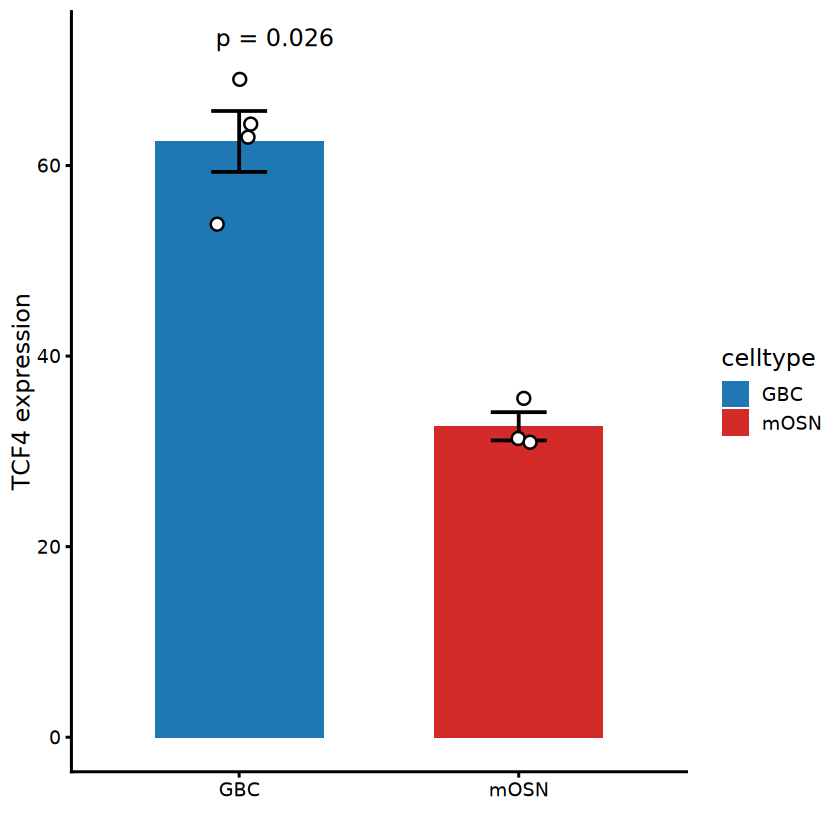

pdf 
  2

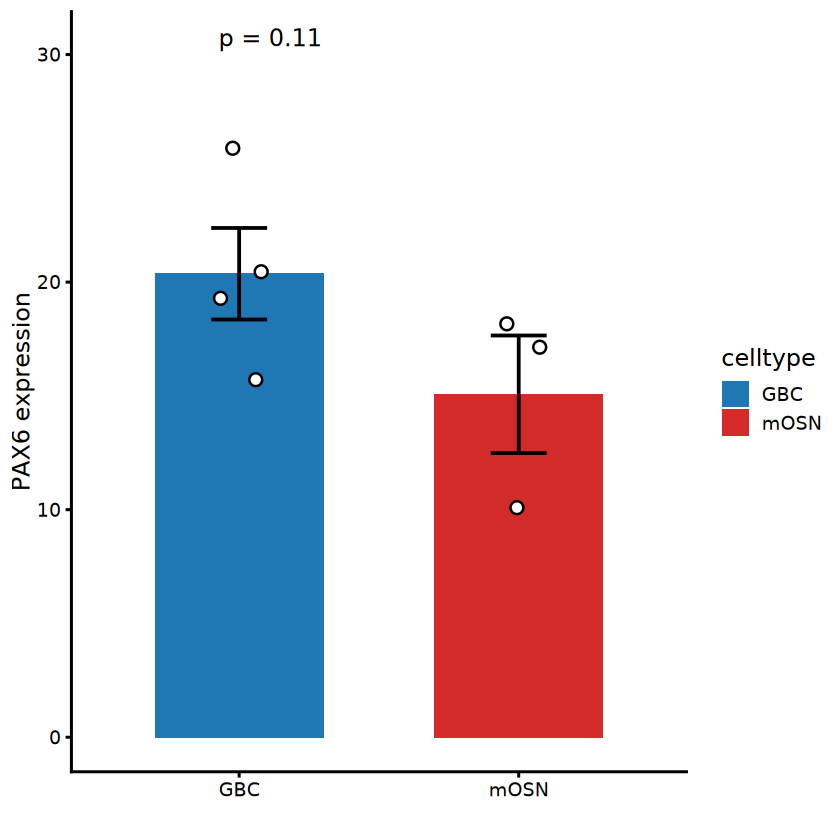

pdf 
  2

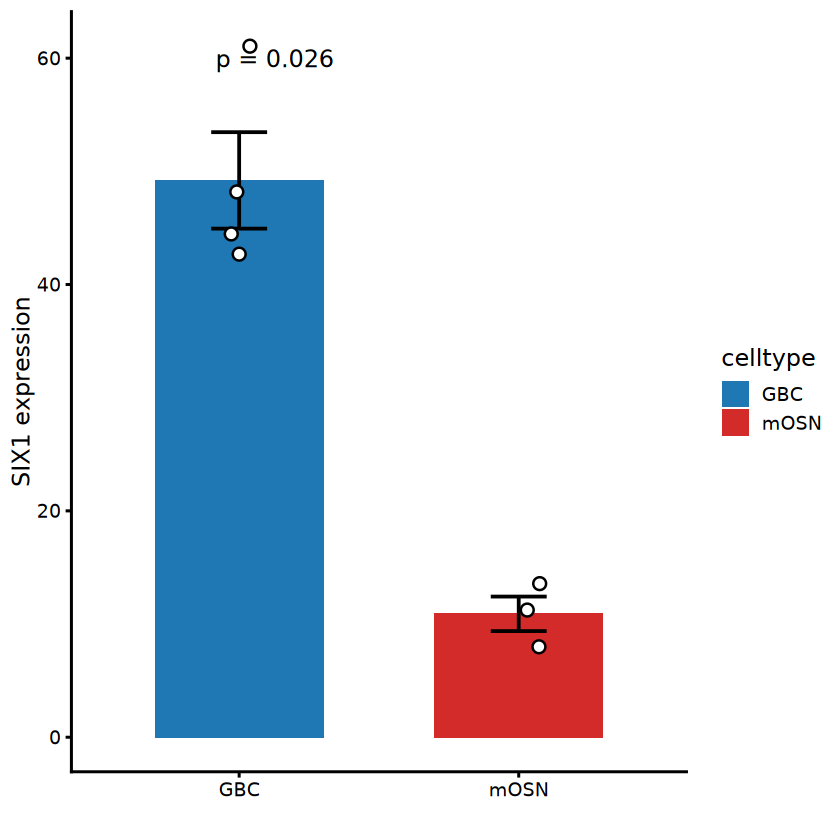

pdf 
  2

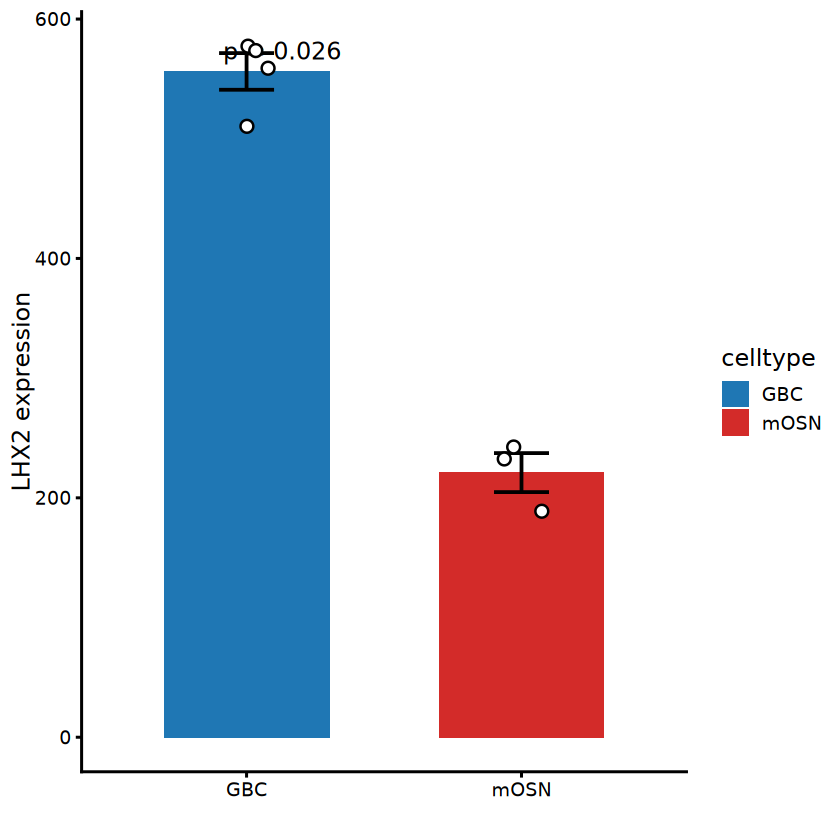

In [41]:
plot_gene_boxplot <- function(gene){
    mouse_gene_exp <- as.data.frame(t(mouse[c(gene),c('GBC_3','GBC_7','GBC_9','GBC_16','mOSN_2','mOSN_7','mOSN_16')]))
    mouse_gene_exp$celltype <- str_split(rownames(mouse_gene_exp), '_',simplify = T)[,1]
    colnames(mouse_gene_exp)[1] <- 'value'

    summary_df <- mouse_gene_exp %>%
      group_by(celltype) %>%
      summarise(
        mean_val = mean(value),
        se = sd(value) / sqrt(n())
      )
 
    ggplot(summary_df, aes(x = celltype, y = mean_val, fill = celltype)) +
    
      geom_bar(stat="identity", width = 0.6) +
      geom_errorbar(aes(ymin = mean_val - se, ymax = mean_val + se),
                    width = 0.2, size=0.8) +
      scale_fill_manual(values = c("GBC"='#1f77b4', "mOSN"="#D32B29")) +
      labs(y = paste(gene ,"expression"), x = "") +
      theme_classic(base_size = 14) +
      stat_compare_means(
        data = mouse_gene_exp,
        aes(x = celltype, y = value),
        method = "wilcox.test",
          method.args = list(
        alternative = "less"
    ),
        label = "p",
        label.y = max(summary_df$mean_val) + 10
      )+
geom_jitter(
            data = mouse_gene_exp,
            aes(x = celltype, y = value),
            inherit.aes = FALSE,
            width = 0.08,
            size = 2.8,
            shape = 21,
            stroke = 0.8,
            fill = "white",
            color = "black"
        ) 


}
plot_gene_boxplot('TCF4')
dev.print(pdf, file='../figures/NC/TCF4_mouse2.pdf', width=3.5, height=4)
plot_gene_boxplot('PAX6')
dev.print(pdf, file='../figures/NC/PAX6_mouse2.pdf', width=3.5, height=4)
plot_gene_boxplot('SIX1')
dev.print(pdf, file='../figures/NC/SIX1_mouse2.pdf', width=3.5, height=4)
plot_gene_boxplot('LHX2')
dev.print(pdf, file='../figures/NC/LHX2_mouse2.pdf', width=3.5, height=4)

# plot_gene_boxplot('SHANK3')
# plot_gene_boxplot('ZNF462')

# plot_gene_boxplot('SIX1')
# plot_gene_boxplot('SLC45A1')
# plot_gene_boxplot('SCN1A')



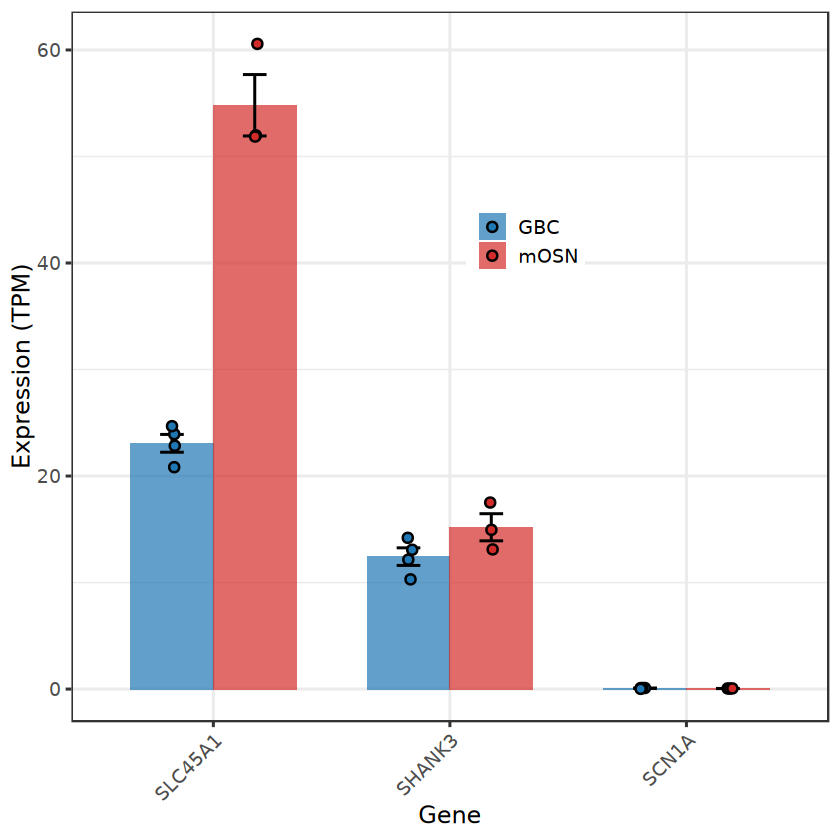

In [35]:

library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(ggpubr)


sample_cols <- c(
  'GBC_3','GBC_7','GBC_9','GBC_16',
  'mOSN_2','mOSN_7','mOSN_16'
)
genes <- c('SLC45A1','SHANK3','SCN1A')
df <- as.data.frame(t(mouse[genes, sample_cols]))

df$celltype <- str_split(rownames(df), '_', simplify = TRUE)[,1]
df$sample   <- rownames(df)

# wide → long
df_long <- df %>%
  pivot_longer(cols = all_of(genes), names_to="gene", values_to="value")

summary_df <- df_long %>%
  group_by(gene, celltype) %>%
  summarise(
    mean_val = mean(value),
    se = sd(value) / sqrt(n()),
    .groups = "drop"
  )


celltype_cols <- c("GBC"='#1f77b4', "mOSN"="#D32B29")

p <- ggplot(summary_df,
            aes(x = factor(gene, levels = genes), y = mean_val, fill = celltype)) +
  geom_bar(stat="identity", position="dodge", width = 0.7, alpha=0.7) +
  geom_errorbar(aes(ymin = mean_val - se, ymax = mean_val + se),
                position = position_dodge(0.7), width = 0.2) +
  scale_fill_manual(values = celltype_cols) +
  labs(x = "Gene", y = "Expression (TPM)", fill = "") +
  theme_bw(base_size = 14) +
  theme(axis.text.x = element_text(angle=45, hjust=1), legend.position = c(0.6,0.7))+
    geom_jitter(
    data = df_long,
    aes(x = gene, y = value, color=celltype),
    shape = 21,
    size = 2,
    stroke = 0.8,
    color = "black",
    position = position_jitterdodge(
        dodge.width = 0.7,   # 与geom_bar一致
        jitter.width = 0.08
    )
)

p
ggsave(p, file='../figures/NC/g2g_vali2.pdf', width=3.8, height=4)

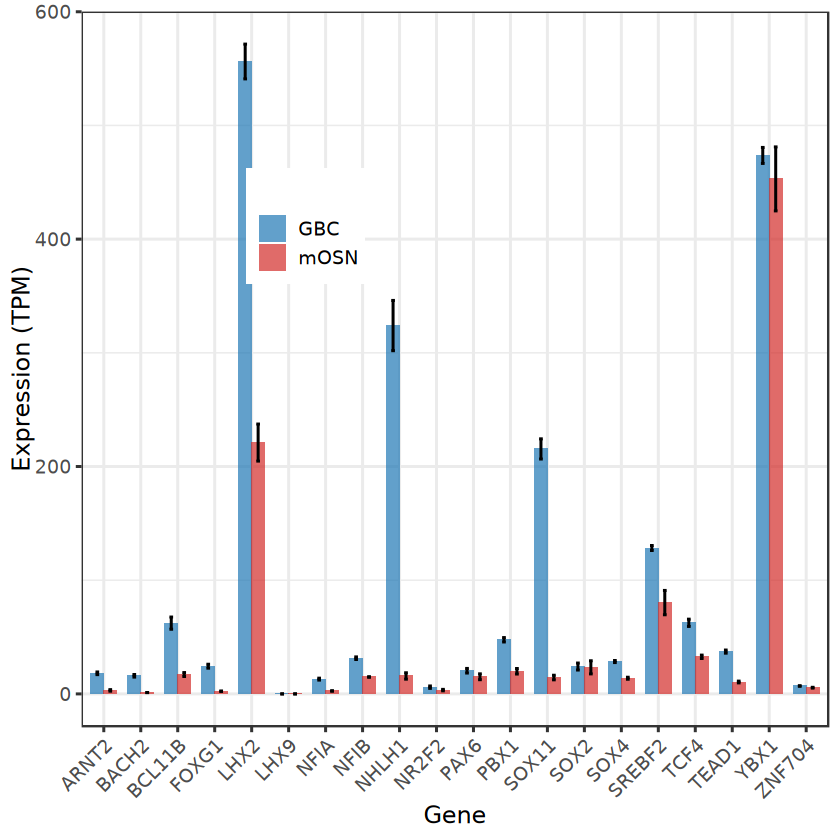

In [312]:
genes <- c('SOX2','PAX6','LHX9','SOX4','LHX2', 'SOX11','PBX1','FOXG1','NR2F2','TCF4',
           #'ZNF85','HMGA2''POU6F2',
           'YBX1' ,'TEAD1','NFIA','NHLH1','BCL11B','BACH2','NFIB','TCF4','ARNT2','SREBF2','ZNF704')
df <- as.data.frame(t(mouse[genes, sample_cols]))

df$celltype <- str_split(rownames(df), '_', simplify = TRUE)[,1]
df$sample   <- rownames(df)

# wide → long
df_long <- df %>%
  pivot_longer(cols = all_of(genes), names_to="gene", values_to="value")

summary_df <- df_long %>%
  group_by(gene, celltype) %>%
  summarise(
    mean_val = mean(value),
    se = sd(value) / sqrt(n()),
    .groups = "drop"
  )


celltype_cols <- c("GBC"='#1f77b4', "mOSN"="#D32B29")

p <- ggplot(summary_df,
            aes(x = gene, y = mean_val, fill = celltype)) +
  geom_bar(stat="identity", position="dodge", width = 0.7, alpha=0.7) +
  geom_errorbar(aes(ymin = mean_val - se, ymax = mean_val + se),
                position = position_dodge(0.7), width = 0.2) +
  scale_fill_manual(values = celltype_cols) +
  labs(x = "Gene", y = "Expression (TPM)", fill = "") +
  theme_bw(base_size = 14) +
  theme(axis.text.x = element_text(angle=45, hjust=1), legend.position = c(0.3,0.7))
p
ggsave(p, file='./figures/NC/g2g_vali_tf.pdf', width=3.8, height=4)

In [313]:
alignment_cluster  <- read.table('data/G2G/G2G_en_goldstein_psyad_sfari_14.txt', sep='\t')
alignment_similarity <- read.table('data/G2G/G2G_en_goldstein_psyad_sfari_14_similarity.txt',sep='\t',header = T )

In [314]:

SFARI = read.table('/sc/arion/projects/roussp01a/liting/Olf/data/SFARI.txt', sep='\t', header = T)#.Symbol#[1:81]
SFARI <- subset(SFARI,syndromic==1| gene.score==1)

Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“EOF within quoted string”
Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”


In [315]:
dev_files <- list.files('/sc/arion/projects/roussp01a/liting/Olf/data/lister_devDEG/', '.txt')
dev_gs <- c()
for(fl in dev_files){
  dev_g <- read.table(paste0('/sc/arion/projects/roussp01a/liting/Olf/data/lister_devDEG/',fl),header = T)
  cell_type <- gsub('\\.txt|-','',fl)
  dev_g$celltype <- cell_type
  dev_gs <- rbind(dev_g,dev_gs)
}

dev_gs <- subset(dev_gs, !grepl('^MT|^LINC|^MIR|^RP',gene_name ))# & celltype=="L23_CUX2")
dev_gs <- dev_gs[!duplicated(dev_gs$gene_name),]

In [316]:
rownames(dev_gs) <- dev_gs$gene_name
mouse <- subset(mouse, human_gene%in%SFARI$gene.symbol)

In [317]:
library("ComplexHeatmap")


In [318]:

normalize <- function(x) {
  return((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}
scale_d <- function(x){
    xx <- t(apply(x,1, normalize))
    colnames(xx) <- colnames(x)
    xx
}




column_ha = HeatmapAnnotation(celltypes = c(rep('INP',4) ,rep('OSN',3)), 
                              day = c(3,7,9,16,2,7,16)
                             #col = ha_cols
                             )

scale_mouse <- scale_d(mouse[,c('GBC_3','GBC_7','GBC_9','GBC_16','mOSN_2','mOSN_7','mOSN_16')])
scale_mouse <- scale_mouse[!is.na(rowSums(scale_mouse)),]
row_ha <- rowAnnotation(Anno=dev_gs[rownames(scale_mouse),'trend_class']
                        #col = ha_cols
                       ) 
p_dar <- ComplexHeatmap::pheatmap(scale_mouse,
        cluster_rows = T, 
            row_gap = unit(3, "mm"), 
        cluster_cols = F,
              
                                  show_rownames = F,
            left_annotation = row_ha,
                 row_km=2,
             name = "TPM", top_annotation = column_ha
            )


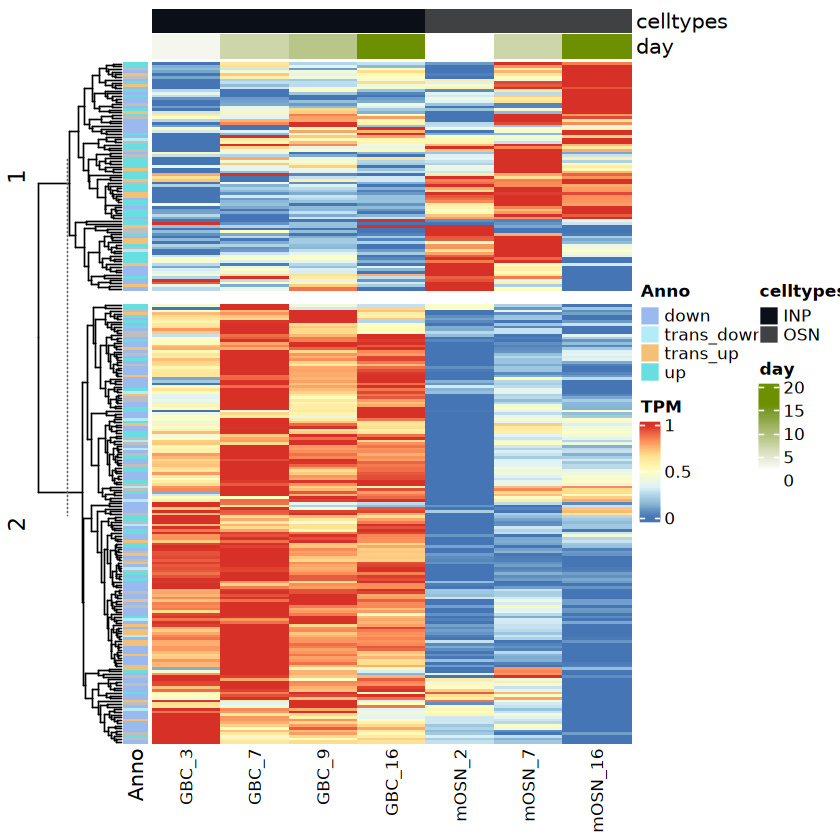

In [319]:
p_dar <- draw(p_dar)

In [320]:
rownames(alignment_similarity) <- alignment_similarity$Gene

In [321]:
row_groups <- row_order(p_dar) 

names(row_groups) <- paste0('cl',1:length(row_groups))
sfari_clusters <- do.call(rbind, lapply(names(row_groups), function(i) {
              data.frame(cluster = i,
                         gene = rownames(scale_mouse)[row_groups[[i]]]
            )}))

In [322]:
sfari_clusters$CEN_trend <- dev_gs[sfari_clusters$gene,'trend_class']
sfari_clusters$similarity <-  alignment_similarity[sfari_clusters$gene, 'alignment_similarity_percentage']

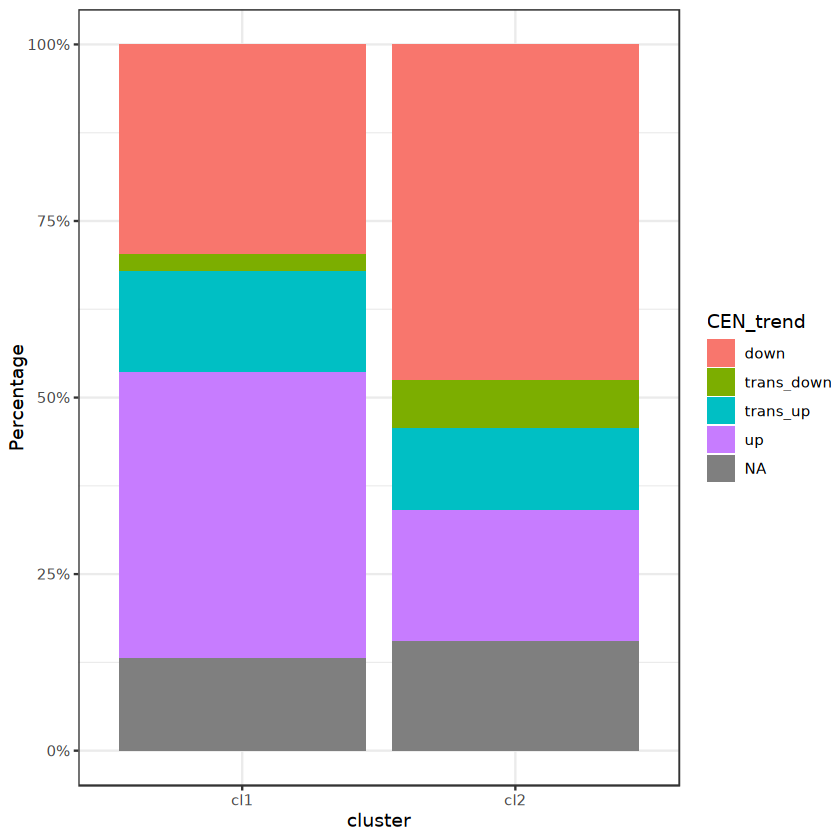

In [323]:
library(ggplot2)
ggplot(sfari_clusters, aes(x = cluster, fill = CEN_trend)) +
    geom_bar(position = "fill") +
    scale_y_continuous(labels = scales::percent) +
    theme_bw() +
    labs(y = "Percentage")

In [324]:
sfari_clusters$OSN_trend <- ifelse(sfari_clusters$cluster=='cl1' , 'up', 'down')
nrow(sfari_clusters)

[1] 246

In [325]:
77/(77+25)##down
34/(34+30)##up

[1] 0.754902

[1] 0.53125

In [326]:
sfari_clusters$CEN_trend[is.na(sfari_clusters$CEN_trend )] <- 'non_DEG'

In [327]:
xtabs(~OSN_trend+CEN_trend,sfari_clusters )

         CEN_trend
OSN_trend down non_DEG trans_down trans_up up
     down   77      25         11       19 30
     up     25      11          2       12 34

In [329]:
sum(c(77  ,    25    ,     11  ,     19, 30))
sum(c(25 ,     11  ,        2   ,    12, 34))

[1] 162

[1] 84

In [333]:
library(VennDiagram) 
pdf("/sc/arion/projects/roussp01a/liting/Olf/figures/NC/venn_down_vali.pdf", width = 6, height = 6)
down <- venn.diagram(list(
  `CEN: down` = subset(sfari_clusters, CEN_trend=='down')$gene,
    `OSN: down` =  subset(sfari_clusters, OSN_trend=='down')$gene) , fill = c("#0073C2FF", "#EFC000FF"), 
             alpha = c(0.5, 0.5), lwd =0, filename = NULL,#"/sc/arion/projects/roussp01a/liting/Olf/figures/NC/venn_diagram_1000vs1000_TF.png", 
                   height = 1000, 
    width = 2000 )

grid.draw(down)
dev.off()

pdf("/sc/arion/projects/roussp01a/liting/Olf/figures/NC/venn_up_vali.pdf", width = 6, height = 6)
up <- venn.diagram(list(
  `CEN: up` = subset(sfari_clusters, CEN_trend=='up')$gene,
    `OSN: up` =  subset(sfari_clusters, OSN_trend=='up')$gene) , fill = c("#0073C2FF", "#EFC000FF"), 
             alpha = c(0.5, 0.5), lwd =0, filename = NULL,#"/sc/arion/projects/roussp01a/liting/Olf/figures/NC/venn_diagram_1000vs1000_TF.png", 
                   height = 1000, 
    width = 2000 )

grid.draw(up)
dev.off()

Loading required package: futile.logger


Attaching package: ‘VennDiagram’


The following object is masked from ‘package:ggpubr’:

    rotate




pdf 
  2

pdf 
  2

In [330]:
# down
N <- 246  
K <- 102   
n <- 162 
k <- 77    


p_value <- phyper(k - 1, K, N - K, n, lower.tail = FALSE)


expected <- (n * K) / N
fold_enrichment <- k / expected

print(paste("P-value:", p_value))
print(paste("Fold Enrichment:", fold_enrichment))

[1] "P-value: 0.00511613384183242"
[1] "Fold Enrichment: 1.14633260711692"


In [331]:
#up
N <- 246  
K <- 84   
n <- 64   
k <- 34   

# 
p_value <- phyper(k - 1, K, N - K, n, lower.tail = FALSE)

# 
expected <- (n * K) / N
fold_enrichment <- k / expected

print(paste("P-value:", p_value))
print(paste("Fold Enrichment:", fold_enrichment))

[1] "P-value: 0.000219870207471794"
[1] "Fold Enrichment: 1.55580357142857"


pdf 
  2

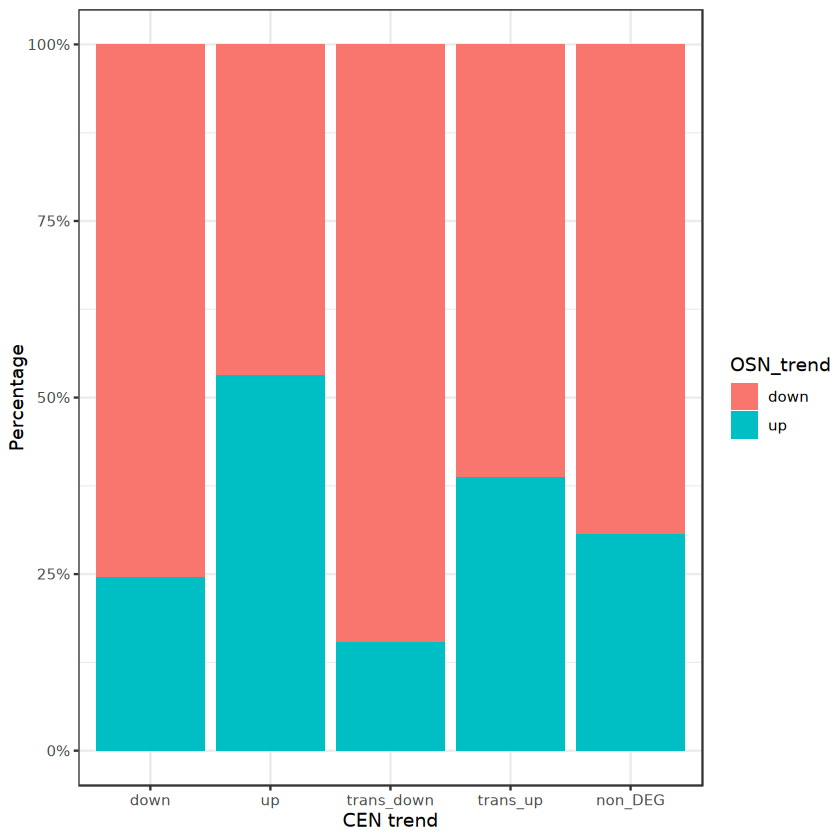

In [272]:
library(ggplot2)
ggplot(sfari_clusters, aes(x =factor(CEN_trend, levels = c('down','up','trans_down','trans_up','non_DEG')) , fill = OSN_trend)) +
    geom_bar(position = "fill") +
    scale_y_continuous(labels = scales::percent) +
    theme_bw() +
    labs(y = "Percentage", x='CEN trend')

dev.print(pdf, file='./figures/NC/asd_cen_osn_trend.pdf', width=5, height=5)